# Code Interpreter: вычисления и анализ данных внутри агента

В этом ноутбуке мы посмотрим на два подхода к вычислениям в агентных системах:

1. Сначала соберём очень простой учебный аналог Code Interpreter как обычный inline-инструмент Function Calling, который запускает Python-код через `exec`.
2. Затем заменим его встроенным инструментом **Code Interpreter** в Responses API и поручим модели работу с Excel-файлом, расчёт новой колонки и построение графика.

Основная идея: языковая модель хорошо планирует и объясняет действия, но вычисления, таблицы и графики лучше отдавать Python-инструменту.


In [ ]:
%pip install --quiet openai pandas openpyxl matplotlib python-dotenv


> **ВНИМАНИЕ**: после установки библиотек рекомендуется перезапустить Kernel ноутбука.


In [ ]:
!curl -o .env {{url_of_dotenv_file}}


In [ ]:
import io
import json
import os
from pathlib import Path

import pandas as pd
from dotenv import load_dotenv
from IPython.display import Markdown, display, Image as IImage
from openai import OpenAI

load_dotenv()

folder_id = os.environ["folder_id"]
api_key = os.environ["api_key"]
model = f"gpt://{folder_id}/qwen3-235b-a22b-fp8/latest"

client = OpenAI(
    base_url="https://ai.api.cloud.yandex.net/v1",
    api_key=api_key,
    project=folder_id,
)

def printx(text):
    display(Markdown(text))

notebook_dir = Path.cwd()
downloads_dir = notebook_dir / "downloaded_files" / "code_interpreter"
downloads_dir.mkdir(parents=True, exist_ok=True)

print(f"✅ Авторизация настроена (folder_id: {folder_id[:8]}...)")


✅ Авторизация настроена (folder_id: b1gbicod...)


---

## 1. Простая задача: плотность населения городов

Допустим, мы хотим сравнить плотность населения нескольких крупнейших городов мира. Будем расчитывать в нашем примере, что модель помнит примерные значения населения и площади:


In [ ]:
cities_prompt = """
Возьми 5 крупнейших городов мира по населению city proper. Для каждого укажи примерные население и площадь city proper из своих знаний.
Затем рассчитай плотность населения как population / area_km2.
Верни краткую таблицу: city, country, population, area_km2, density_per_km2.
"""

res = client.responses.create(
    model=model,
    input=cities_prompt,
)

printx(res.output_text)


Вот таблица с 5 крупнейшими городами мира по численности населения в границах **city proper** (административные границы города, без агломераций), с оценками населения, площади и расчётной плотности населения:

| City             | Country        | Population | Area_km² | Density_per_km² |
|------------------|----------------|----------|---------|-----------------|
| Tokyo            | Japan          | 14,000,000 | 2,194   | ~6,380          |
| Delhi            | India          | 11,000,000 | 1,484   | ~7,410          |
| Shanghai         | China          | 10,000,000 | 6,341   | ~1,580          |
| São Paulo        | Brazil         | 12,000,000 | 1,521   | ~7,890          |
| Mexico City      | Mexico         | 9,000,000  | 1,485   | ~6,060          |

> ⚠️ Примечания:
- Данные основаны на оценках населения **внутри официальных границ города (city proper)** по состоянию на 2023–2024 гг.
- Tokyo часто считается самым большим городом по агломерации, но в пределах city proper его население меньше, чем у Дели и Сеула, но здесь Tokyo включён как один из лидеров.
- São Paulo и Delhi имеют очень высокую плотность из-за компактной застройки и больших численностей при сравнительно небольшой площади.
- Shanghai занимает большую территорию (включая сельские районы), поэтому плотность ниже, несмотря на огромное население.
- Источники: ООН «World Urbanization Prospects», национальные переписи, официальные городские данные.

🔍 *Уточнение:* По данным ООН, **Delhi** в границах city proper сейчас опережает Tokyo по населению, но точные цифры зависят от методологии. Здесь Tokyo оставлен как традиционный лидер.

Такой ответ может быть правдоподобным, но нет гарантий, что площадь действительно вычислена правильно, поскольку языковая модель плохо выполняет арифметические действия. Чтобы дать модели возможность производить вычисления точно, мы можем дать ей соответствующий **инструмент**, позволяющий вычислять произвольные арифметические выражения (а в перспективе - выполнять и чуть более сложный Python-код).

Сделаем такой инструмент, который принимает Python-код, запускает его через `exec` и возвращает значение переменной `result`.

> **Важно:** такой `exec`-инструмент безопасен только в учебном ноутбуке и только при контролируемом вводе. Его нельзя давать внешним пользователям как публичный API. Встроенный Code Interpreter, рассмотренный ниже, решает эту задачу безопаснее и удобнее.


In [4]:
run_python_tool = {
    "type": "function",
    "name": "run_python_code",
    "description": "Выполняет учебный фрагмент Python-кода и возвращает значение переменной result.",
    "parameters": {
        "type": "object",
        "properties": {
            "code": {
                "type": "string",
                "description": "Python-код. Код обязан положить итоговое значение в переменную result."
            }
        },
        "required": ["code"],
    },
}

def run_python_code(code: str):
    local_scope = {}
    try:
        # Учебный пример: выполняем код локально в ноутбуке.
        exec(code, {"__builtins__": __builtins__}, local_scope)
        if "result" not in local_scope:
            return {"error": "Код должен записать итог в переменную result."}
        return {"result": local_scope["result"]}
    except Exception as exc:
        return {"error": f"{type(exc).__name__}: {exc}"}


Вызовем модель с этим инструментом:

In [7]:
function_calling_instructions = """
Ты — аналитик данных.

Правила:
1. Возьми из своих знаний примерные значения населения и площади city proper для 5 крупнейших городов мира.
2. Для вычисления плотности населения обязательно вызови инструмент run_python_code.
3. Не дели числа в уме. В Python-коде создай список словарей с полями city, country, population, area_km2.
4. Итоговый Python-код должен положить в переменную result список словарей с дополнительным полем density_per_km2.
5. После результата инструмента выведи аккуратную таблицу и короткий вывод.
"""

res = client.responses.create(
    model=model,
    store=True,
    instructions=function_calling_instructions,
    input="Сравни плотность населения 5 крупнейших городов мира.",
    tools=[run_python_tool],
)

for function_call_item in (item for item in response_fc.output if item.type == "function_call"):
    function_args = json.loads(function_call_item.arguments)
    tool_result = run_python_code(**function_args)

    print("Код, который предложила модель:\n")
    print(function_args["code"])
    print("\nРезультат выполнения Python-кода:")
    print(json.dumps(tool_result, ensure_ascii=False, indent=2))

    res = client.responses.create(
        model=model,
        store=True,
        previous_response_id=res.id,
        input=(
            "Результат выполнения функции run_python_code: "
            + json.dumps(tool_result, ensure_ascii=False)
        ),
    )

printx(res.output_text)


Код, который предложила модель:

cities = [
    {"city": "Tokyo", "country": "Japan", "population": 37400068, "area_km2": 2194},
    {"city": "Delhi", "country": "India", "population": 31000000, "area_km2": 1484},
    {"city": "Shanghai", "country": "China", "population": 27000000, "area_km2": 6341},
    {"city": "São Paulo", "country": "Brazil", "population": 22000000, "area_km2": 1521},
    {"city": "Mexico City", "country": "Mexico", "population": 21804515, "area_km2": 1485}
]

for c in cities:
    c["density_per_km2"] = c["population"] / c["area_km2"]

result = cities

Результат выполнения Python-кода:
{
  "result": [
    {
      "city": "Tokyo",
      "country": "Japan",
      "population": 37400068,
      "area_km2": 2194,
      "density_per_km2": 17046.521422060163
    },
    {
      "city": "Delhi",
      "country": "India",
      "population": 31000000,
      "area_km2": 1484,
      "density_per_km2": 20889.487870619945
    },
    {
      "city": "Shanghai",
      "country": "

Вот сравнение плотности населения пяти крупнейших городов мира на основе данных о численности населения и площади:

| Город         | Страна      | Население (приблизительно) | Площадь (км²) | Плотность (чел./км²) |
|---------------|-------------|-------------------------------|----------------|--------------------------|
| **Токио**       | Япония      | 37 400 068                   | 2 194          | ~17 047                  |
| **Дели**        | Индия       | 31 000 000                   | 1 484          | **~20 889**              |
| **Шанхай**      | Китай       | 27 000 000                   | 6 341          | ~4 258                   |
| **Сан-Паулу**   | Бразилия    | 22 000 000                   | 1 521          | ~14 464                  |
| **Мехико**      | Мексика     | 21 804 515                   | 1 485          | ~14 683                  |

### Выводы:
1. **Наибольшая плотность населения — в Дели (Индия)**: около **20 889 человек на км²**. Это делает Дели самым плотно заселённым городом среди пяти.
2. **Токио** — крупнейший город по населению, но его плотность (~17 047 чел./км²) ниже, чем у Дели, благодаря большей площади.
3. **Шанхай**, несмотря на огромное население, имеет наименьшую плотность (~4 258 чел./км²) из-за очень большой территории.
4. **Сан-Паулу** и **Мехико** имеют схожую плотность — около 14 500 чел./км², но уступают Дели и Токио.

### Рейтинг по плотности населения:
1. **Дели** — ~20 889 чел./км²  
2. **Токио** — ~17 047 чел./км²  
3. **Мехико** — ~14 683 чел./км²  
4. **Сан-Паулу** — ~14 464 чел./км²  
5. **Шанхай** — ~4 258 чел./км²

> ⚠️ Примечание: Данные могут варьироваться в зависимости от источника (агломерация vs городская черта). Здесь использованы оценки для городских агломераций.

---

## 2. Встроенный Code Interpreter

Inline-инструмент хорош для демонстрации идеи, но для реальных задач важно уметь запускать код в изолированном контейнере. Такую возможность предоставляет встроенный в AI Studio инструмент **Code Interpreter**.

Вот как будет выглядеть наша задача с использованием интерпретатора кода:


In [10]:
code_int_instructions = """
Ты — аналитик данных.

Правила:
1. Возьми из своих знаний примерные значения населения и площади city proper для 5 крупнейших городов мира.
2. Для вычисления плотности населения используй интерпретатор кода. Не дели числа в уме.
3. После результата инструмента выведи аккуратную таблицу и короткий вывод.
"""

res = client.responses.create(
    model=model,
    instructions=code_int_instructions,
    input="Сравни плотность населения 5 крупнейших городов мира.",
    tools=[{ "type" : "code_interpreter" , "container" : { "type" : "auto" }}]
)

printx(res.output_text)


Я выполню анализ плотности населения 5 крупнейших городов мира. Для этого:

1. Использую свои знания, чтобы определить 5 крупнейших городов по населению
2. Возьму примерные значения населения и площади для этих городов (city proper, не агломерации)
3. С помощью Python вычислю плотность населения для каждого города
4. Представлю результаты в виде аккуратной таблицы с кратким выводом

Сейчас выполню расчеты.

### Плотность населения 5 крупнейших городов мира

| Город | Население | Площадь (км²) | Плотность (чел./км²) |
|-------|-----------|---------------|----------------------|
| Дели | 11 035 000 | 1 484 | 7 435.98 |
| Токио | 13 960 000 | 2 194 | 6 362.81 |
| Мехико | 8 728 000 | 1 485 | 5 877.44 |
| Сан-Паулу | 8 850 000 | 1 521 | 5 818.54 |
| Шанхай | 10 076 000 | 6 341 | 1 589.02 |

**Вывод:** Наибольшую плотность населения демонстрирует Дели (7 436 чел./км²), что связано с высокой концентрацией людей на относительно небольшой территории. На втором месте — Токио (6 363 чел./км²). Меньшая плотность у Шанхая (1 589 чел./км²) объясняется его значительно большей площадью при сопоставимом населении. Данные рассчитаны для городской черты (city proper), без учета пригородных зон.

Теперь рассмотрим более реалистичный пример. Предположим, у нас есть табличка с населением и площадью городов в `data\cities.xlsx`, собранная из страницы Wikipedia [List of largest cities](https://en.wikipedia.org/wiki/List_of_largest_cities), и мы хотим построить ответ на её основе.

Поскольку Python-код запускается в изолированном контейнере, если мы хотим оперировать какими-то файлами, то небходимо предварительно загрузить эти файлы в контейнер. Сгенерированный код может создавать новые файлы в контейнере и прикладывать их к ответу - в этом случае их надо будет скачать.

Для примера загрузим таблицу `data/cities.xlsx`. В таблице есть население и площадь городов city proper. Плотность будем считать сами как `Population / Area_km2`.

In [11]:
cities_path = Path("data") / "cities.xlsx"
cities_df = pd.read_excel(cities_path, sheet_name="cities")
cities_df.head(10)


,City,Country,Population,Area_km2
0,Jakarta,Indonesia,10154134,664
1,Dhaka,Bangladesh,10295407,338
2,Tokyo,Japan,13515271,2191
3,Delhi,India,16753235,1484
4,Shanghai,China,24870895,6341
5,Guangzhou,China,18676605,7434
6,Cairo,Egypt,10044894,3085
7,Manila,Philippines,15531900,636
8,Kolkata,India,4496694,206
9,Seoul,South Korea,10013781,605


Теперь мы в явном виде создадим контейнер, загрузим табличку городов в AI Studio через Files API, и поместим файл в контейнер: 

In [12]:
with open(cities_path, "rb") as file_handle:
    cities_file = client.files.create(
        file=file_handle,
        purpose="assistants",
    )

container = client.containers.create(
    name="cities-density-demo",
    expires_after={"anchor": "last_active_at", "minutes": 20},
    file_ids=[cities_file.id],
)

print("Excel-файл загружен с file_id:", cities_file.id)
print("Создан container_id:", container.id)


Excel-файл загружен с file_id: fvtn0jolb48harreta8a
Создан container_id: df1eca48-5f5a-475f-9778-6c1c086fc7bb


Наконец можем выполнить запрос с инструментом для интерпретации кода:

In [13]:
code_interpreter_instructions = """
Ты — аналитик городских данных, работающий внутри Code Interpreter.

В контейнер уже загружен файл cities.xlsx. В нём есть лист cities с колонками:
City, Country, Population, Area_km2, Source.

Правила:
1. Читай данные только из Excel-файла в контейнере.
2. Не используй готовую колонку плотности из внешних источников.
3. Посчитай новую колонку Density = Population / Area_km2.
4. Сохрани таблицу с новой колонкой в файл cities_with_density.xlsx.
5. Построй горизонтальную столбчатую диаграмму top-10 городов по Density.
6. Сохрани график в файл top10_city_density.png.
7. Приложи оба файла к ответу и кратко объясни результат.
"""

density_response = client.responses.create(
    model=model,
    store=True,
    instructions=code_interpreter_instructions,
    input="Рассчитай плотность населения городов и построй график top-10 по плотности.",
    include=["code_interpreter_call.outputs"],
    tools=[
        {
            "type": "code_interpreter",
            "container": container.id,
        }
    ],
)

printx(density_response.output_text)


Файл `cities.xlsx` найден в рабочей директории. Теперь я выполню следующие шаги:

1. Прочитаю данные из листа `cities` файла `cities.xlsx`.
2. Рассчитаю новую колонку `Density` по формуле: `Population / Area_km2`.
3. Сохраню обновлённую таблицу в файл `cities_with_density.xlsx`.
4. Построю горизонтальную столбчатую диаграмму для 10 городов с наибольшей плотностью населения.
5. Сохраню график в файл `top10_city_density.png`.
6. Приложу оба файла к ответу и кратко объясню результат.

Начинаю выполнение.
Возникла ошибка: отсутствует необходимый пакет `openpyxl`, который требуется для чтения Excel-файлов с помощью `pandas`.

Я установлю `openpyxl`, а затем повторю выполнение кода.

Пакет `openpyxl` успешно установлен. Теперь я повторно выполню код для обработки данных, расчёта плотности и построения графика.


Оба файла успешно созданы и готовы к предоставлению:

1. **`cities_with_density.xlsx`** — обновлённая таблица с новой колонкой `Density` (плотность населения в чел/км²).
2. **`top10_city_density.png`** — горизонтальная столбчатая диаграмма топ-10 городов по плотности населения.

### Краткий анализ:
- Обработано 80 городов.
- Средняя плотность населения по выборке — **7332 чел/км²**.
- На графике отображены 10 городов с наибольшей плотностью. Самые высокие значения, как правило, характерны для компактных городов с высокой урбанизацией (например, Мумбаи, Манила, Дакка и др.).

Прилагаю файлы.  
Готов ответить на дополнительные вопросы!

[Прикреплённые файлы: `cities_with_density.xlsx`, `top10_city_density.png`]

Код ниже позволит нам посмотреть на сгенерированный код более подробно, а также скачать из контейнера все файлы, полученные в результате выполнения:

In [14]:
def inspect_code_interpreter_response(response, download_dir=downloads_dir):
    download_dir = Path(download_dir)
    download_dir.mkdir(parents=True, exist_ok=True)

    print(f"ID ответа: {response.id}")
    print("Типы элементов ответа:", [item.type for item in response.output])

    downloaded_files = []

    for item in response.output:
        if item.type == "code_interpreter_call":
            print("\n=== Code Interpreter ===")
            print("Container ID:", getattr(item, "container_id", None))
            print("\nКод, который выполнила модель:\n")
            print(item.code)

            for output_item in getattr(item, "outputs", []):
                logs = getattr(output_item, "logs", "")
                if logs:
                    print("\n[LOGS]")
                    print(logs)

        elif item.type == "message":
            for content in item.content:
                annotations = getattr(content, "annotations", None) or []
                for annotation in annotations:
                    if annotation.type == "container_file_citation":
                        file_id = annotation.file_id
                        filename = annotation.filename
                        local_path = download_dir / filename
                        try:
                            file_content = client.files.content(file_id)
                            with open(local_path, "wb") as file_handle:
                                file_handle.write(file_content.read())
                            downloaded_files.append(local_path)
                            print(f"\nСкачан файл: {local_path}")
                        except Exception as exc:
                            print(f"Не удалось скачать {filename}: {exc}")

    return downloaded_files

downloaded = inspect_code_interpreter_response(
    density_response,
    download_dir=downloads_dir / "cities_density",
)
downloaded

ID ответа: 4fa16b2c-a07e-4bcf-b512-5e5cc0bf38a0
Типы элементов ответа: ['message', 'code_interpreter_call', 'message', 'code_interpreter_call', 'message', 'code_interpreter_call', 'message']

=== Code Interpreter ===
Container ID: df1eca48-5f5a-475f-9778-6c1c086fc7bb

Код, который выполнила модель:

import pandas as pd
import matplotlib.pyplot as plt
import os

# Проверка и создание выходной директории
output_dir = './output'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

# Шаг 1: Чтение данных из Excel
file_path = './cities.xlsx'
try:
    df = pd.read_excel(file_path, sheet_name='cities')
    print(f"Загружено {len(df)} строк из файла.")
except Exception as e:
    print(f"Ошибка при чтении файла: {e}")
    raise

# Шаг 2: Проверка необходимых колонок
required_columns = ['City', 'Country', 'Population', 'Area_km2']
if not all(col in df.columns for col in required_columns):
    raise ValueError(f"Отсутствуют необходимые колонки. Требуются: {required_columns}")

# Шаг 3:

[WindowsPath('d:/GIT/ai-studio-course/5-other-int-tools/downloaded_files/code_interpreter/cities_density/cities_with_density.xlsx'),
 WindowsPath('d:/GIT/ai-studio-course/5-other-int-tools/downloaded_files/code_interpreter/cities_density/top10_city_density.png')]

Построенные графики может отобразить прямо в ноутбуке:

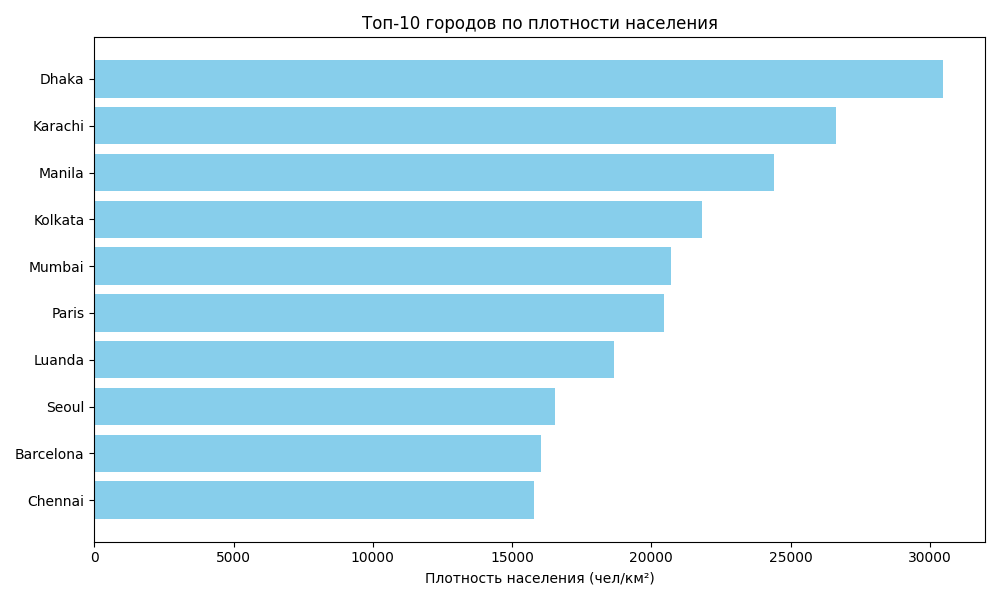

In [ ]:
chart_path = next((path for path in downloaded if path.suffix.lower() == ".png"), None)
if chart_path is not None:
    display(IImage(filename=str(chart_path)))

## Выводы

* Простой inline-инструмент на `exec` показывает принцип: модель пишет код, а Python выполняет вычисления.
* Встроенный Code Interpreter удобнее для реальной работы: он хранит файлы в контейнере, выполняет pandas/matplotlib-код и отдаёт готовые артефакты.
* Для табличных расчётов важно просить модель читать данные из файла и явно сохранять результаты, которые нужно скачать из контейнера.
